# Predicting First-Time Opponent Outcomes From Player Opening Histories


## Analysis Plan
1. Load the cleaned full game-level dataset from `final_data`.
2. Use player names from both `White` and `Black` as the identity keys.
3. Build pre-game history features from each player's earlier openings and results.
4. Keep only games where the two players had never faced each other before.
5. Train a model to predict the outcome of these first-time future meetings.


In [11]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, log_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


## Dataset Requirements
This notebook now uses the cleaned full dataset file with player names, openings, Elo values, and results. No top-30 balanced subsets are used here.


In [12]:
DATA_PATH = Path("/Users/phamhoanghai/Ureca/dataset/final_data")

COLUMN_MAP = {
    "game_id": "GameID",
    "white_player": "White",
    "black_player": "Black",
    "white_elo": "WhiteEloNumeric",
    "black_elo": "BlackEloNumeric",
    "result": "Result",
    "opening_name": "Opening",
    "opening_family": "OpeningFamily",
}

MIN_TOTAL_GAMES_PER_PLAYER = 20
MIN_HISTORY_GAMES = 10
TEST_SIZE = 0.20
RANDOM_STATE = 42


In [13]:
if not DATA_PATH.exists():
    print(f"Dataset not found: {DATA_PATH}")
else:
    raw_df = pd.read_csv(DATA_PATH)
    print("Loaded shape:", raw_df.shape)
    display(raw_df.head())


Loaded shape: (1111082, 13)


,GameID,Event,White,Black,WhiteEloNumeric,BlackEloNumeric,ECO,Opening,EloDiff,AvgElo,Result,NumericResult,OpeningFamily
0,1,Rated Bullet game,sisy,lpaulmp,1645.0,1449.0,D31,Queen's Gambit Declined: Queen's Knight Variation,196.0,1547.0,1-0,1.0,Closed and Semi-Closed
1,2,Rated Blitz game,capablanca1950,ftri67,1603.0,1672.0,C00,French Defense,-69.0,1637.5,0-1,0.0,Open Games and Semi-Open
2,3,Rated Bullet game,daamien,mike81,1166.0,1280.0,D00,Queen's Pawn Game: Steinitz Countergambit,-114.0,1223.0,1-0,1.0,Closed and Semi-Closed
3,4,Rated Blitz game,yaavarmo,JACKELCALVO,1494.0,1449.0,C00,French Defense: Normal Variation,45.0,1471.5,1-0,1.0,Open Games and Semi-Open
4,5,Rated Bullet game,albinofrenchy,galita,1256.0,1285.0,D53,Queen's Gambit Declined: 4.Bg5 Be7,-29.0,1270.5,1-0,1.0,Closed and Semi-Closed


## Standardize And Sort Games
This cell maps the full dataset into a common schema and uses `game_id` as the game-order proxy so player history is built only from earlier games.


In [14]:
def map_result_to_class(result_series: pd.Series) -> pd.Series:
    s = result_series.astype(str).str.strip()
    mapping = {
        "1-0": "win",
        "0-1": "loss",
        "1/2-1/2": "draw",
        "0.5-0.5": "draw",
        "1": "win",
        "0": "loss",
        "0.5": "draw",
        "win": "win",
        "loss": "loss",
        "draw": "draw",
    }
    return s.map(mapping)


def standardize_schema(df: pd.DataFrame, column_map: dict) -> pd.DataFrame:
    reverse_map = {v: k for k, v in column_map.items() if v in df.columns}
    out = df.rename(columns=reverse_map).copy()

    required = [
        "game_id", "white_player", "black_player", "white_elo", "black_elo", "result", "opening_name"
    ]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required standardized columns: {missing}")

    if "opening_family" not in out.columns:
        out["opening_family"] = "Unknown"

    out["game_id"] = pd.to_numeric(out["game_id"], errors="coerce")
    out["outcome"] = map_result_to_class(out["result"])
    out = out.dropna(subset=["game_id", "white_player", "black_player", "white_elo", "black_elo", "opening_name", "outcome"])
    out = out.sort_values(["game_id", "white_player", "black_player"], kind="mergesort").reset_index(drop=True)
    return out


In [15]:
if DATA_PATH.exists():
    df = standardize_schema(raw_df, COLUMN_MAP)

    player_counts = pd.concat([df["white_player"], df["black_player"]], ignore_index=True).value_counts()
    frequent_players = player_counts[player_counts >= MIN_TOTAL_GAMES_PER_PLAYER]

    frequent_df = df[
        df["white_player"].isin(frequent_players.index)
        & df["black_player"].isin(frequent_players.index)
    ].copy()

    print("Standardized shape:", df.shape)
    print("Players with at least", MIN_TOTAL_GAMES_PER_PLAYER, "games:", len(frequent_players))
    print("Games between frequent players:", len(frequent_df))
else:
    print("Waiting for dataset.")


Standardized shape: (1111082, 14)
Players with at least 20 games: 12888
Games between frequent players: 1025440


## Pre-Game History Feature Design
For each game, we use only what each player had done before that game:
- how many games they had already played
- how concentrated or diverse their opening history was
- what their most common openings and opening families were
- how well they had scored historically
- whether the two players had ever met before


In [16]:
from collections import Counter, defaultdict


def shannon_entropy_from_counter(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0:
        return np.nan
    probs = np.array(list(counter.values()), dtype=float) / total
    return float(-(probs * np.log2(probs)).sum())


def extract_top_item(counter: Counter):
    if not counter:
        return "Unknown", 0
    item, count = max(counter.items(), key=lambda kv: (kv[1], kv[0]))
    return item, count


def opposite_outcome(outcome: str) -> str:
    if outcome == "win":
        return "loss"
    if outcome == "loss":
        return "win"
    return "draw"


def build_pre_game_history_features(df: pd.DataFrame) -> pd.DataFrame:
    player_stats = defaultdict(lambda: {
        "games": 0,
        "openings": Counter(),
        "families": Counter(),
        "results": Counter(),
    })
    matchup_counts = Counter()
    feature_rows = []

    for row in df.itertuples(index=False):
        white_stats = player_stats[row.white_player]
        black_stats = player_stats[row.black_player]
        matchup_key = tuple(sorted((row.white_player, row.black_player)))

        white_top_opening, white_top_opening_games = extract_top_item(white_stats["openings"])
        black_top_opening, black_top_opening_games = extract_top_item(black_stats["openings"])
        white_top_family, white_top_family_games = extract_top_item(white_stats["families"])
        black_top_family, black_top_family_games = extract_top_item(black_stats["families"])

        white_games = white_stats["games"]
        black_games = black_stats["games"]

        feature_rows.append({
            "white_history_games": white_games,
            "black_history_games": black_games,
            "white_unique_openings": len(white_stats["openings"]),
            "black_unique_openings": len(black_stats["openings"]),
            "white_unique_families": len(white_stats["families"]),
            "black_unique_families": len(black_stats["families"]),
            "white_opening_entropy": shannon_entropy_from_counter(white_stats["openings"]),
            "black_opening_entropy": shannon_entropy_from_counter(black_stats["openings"]),
            "white_family_entropy": shannon_entropy_from_counter(white_stats["families"]),
            "black_family_entropy": shannon_entropy_from_counter(black_stats["families"]),
            "white_top_opening": white_top_opening,
            "black_top_opening": black_top_opening,
            "white_top_family": white_top_family,
            "black_top_family": black_top_family,
            "white_top_opening_share": white_top_opening_games / white_games if white_games else 0.0,
            "black_top_opening_share": black_top_opening_games / black_games if black_games else 0.0,
            "white_top_family_share": white_top_family_games / white_games if white_games else 0.0,
            "black_top_family_share": black_top_family_games / black_games if black_games else 0.0,
            "white_prior_win_rate": white_stats["results"]["win"] / white_games if white_games else 0.0,
            "black_prior_win_rate": black_stats["results"]["win"] / black_games if black_games else 0.0,
            "white_prior_draw_rate": white_stats["results"]["draw"] / white_games if white_games else 0.0,
            "black_prior_draw_rate": black_stats["results"]["draw"] / black_games if black_games else 0.0,
            "prior_matchups": matchup_counts[matchup_key],
        })

        white_stats["games"] += 1
        white_stats["openings"][row.opening_name] += 1
        white_stats["families"][row.opening_family] += 1
        white_stats["results"][row.outcome] += 1

        black_result = opposite_outcome(row.outcome)
        black_stats["games"] += 1
        black_stats["openings"][row.opening_name] += 1
        black_stats["families"][row.opening_family] += 1
        black_stats["results"][black_result] += 1

        matchup_counts[matchup_key] += 1

    features_df = pd.DataFrame(feature_rows, index=df.index)
    out = pd.concat([df.reset_index(drop=True), features_df.reset_index(drop=True)], axis=1)

    out["entropy_gap"] = out["white_opening_entropy"] - out["black_opening_entropy"]
    out["diversity_gap"] = out["white_unique_openings"] - out["black_unique_openings"]
    out["specialization_gap"] = out["white_top_opening_share"] - out["black_top_opening_share"]
    out["family_focus_gap"] = out["white_top_family_share"] - out["black_top_family_share"]
    out["same_top_family"] = (out["white_top_family"] == out["black_top_family"]).astype(int)
    out["win_rate_gap"] = out["white_prior_win_rate"] - out["black_prior_win_rate"]
    out["draw_rate_gap"] = out["white_prior_draw_rate"] - out["black_prior_draw_rate"]

    return out


In [17]:
if 'frequent_df' in globals():
    history_df = build_pre_game_history_features(frequent_df)

    first_time_df = history_df[history_df["prior_matchups"] == 0].copy()
    model_df = first_time_df[
        (first_time_df["white_history_games"] >= MIN_HISTORY_GAMES)
        & (first_time_df["black_history_games"] >= MIN_HISTORY_GAMES)
    ].copy()

    print("Frequent-player games:", len(frequent_df))
    print("First-time opponent games:", len(first_time_df))
    print("Model rows after history filter:", len(model_df))
    print(model_df["outcome"].value_counts(dropna=False))
    display(model_df.head())
else:
    print("Waiting for frequent-player dataset.")


Frequent-player games: 1025440
First-time opponent games: 574565
Model rows after history filter: 489904
outcome
win     245836
loss    225993
draw     18075
Name: count, dtype: int64


,game_id,Event,white_player,black_player,white_elo,black_elo,ECO,opening_name,EloDiff,AvgElo,...,white_prior_draw_rate,black_prior_draw_rate,prior_matchups,entropy_gap,diversity_gap,specialization_gap,family_focus_gap,same_top_family,win_rate_gap,draw_rate_gap
741,831,Rated Bullet game,faryad22,andrewrun,1831.0,2222.0,A00,Hungarian Opening: Sicilian Invitation,-391.0,2026.5,...,0.0,0.0,0,-1.936678,-7,0.523810,0.404762,0,0.202381,0.0
848,951,Rated Bullet game,laloli,lpaulmp,1391.0,1489.0,C02,"French Defense: Advance Variation, Nimzowitsch...",-98.0,1440.0,...,0.0,0.0,0,1.256612,4,-0.409091,-0.232955,0,-0.039773,0.0
868,976,Rated Bullet game,DolfjeWeerwolfje,Voittamaton,1875.0,1844.0,C66,"Ruy Lopez: Berlin Defense, Improved Steinitz D...",31.0,1859.5,...,0.0,0.0,0,0.470680,5,0.023810,-0.071429,0,0.126984,0.0
884,998,Rated Blitz tournament https://lichess.org/tou...,TapakaH41k,juliocrv,1930.0,1685.0,B25,"Sicilian Defense: Closed Variation, Traditional",245.0,1807.5,...,0.0,0.0,0,0.137504,1,-0.009091,0.127273,1,0.400000,0.0
1026,1157,Rated Blitz tournament https://lichess.org/tou...,TapakaH41k,alembuysakralhenry,1936.0,1271.0,B01,Scandinavian Defense: Mieses-Kotroc Variation,665.0,1603.5,...,0.0,0.0,0,0.000000,0,0.000000,0.307692,1,0.769231,0.0


## Predictive Model
The model is trained only on first-time meetings between players, using each side's opening-and-result history before that game.


In [18]:
NUM_FEATURES = [
    "white_history_games",
    "black_history_games",
    "white_unique_openings",
    "black_unique_openings",
    "white_unique_families",
    "black_unique_families",
    "white_opening_entropy",
    "black_opening_entropy",
    "white_family_entropy",
    "black_family_entropy",
    "white_top_opening_share",
    "black_top_opening_share",
    "white_top_family_share",
    "black_top_family_share",
    "white_prior_win_rate",
    "black_prior_win_rate",
    "white_prior_draw_rate",
    "black_prior_draw_rate",
    "entropy_gap",
    "diversity_gap",
    "specialization_gap",
    "family_focus_gap",
    "same_top_family",
    "win_rate_gap",
    "draw_rate_gap",
    "white_elo",
    "black_elo",
]

CAT_FEATURES = [
    "white_top_opening",
    "black_top_opening",
    "white_top_family",
    "black_top_family",
]


In [19]:
if 'model_df' in globals() and len(model_df) > 0:
    X = model_df[NUM_FEATURES + CAT_FEATURES].copy()
    y = model_df["outcome"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    preprocess = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                NUM_FEATURES,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]),
                CAT_FEATURES,
            ),
        ]
    )

    model = Pipeline([
        ("prep", preprocess),
        (
            "clf",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ])

    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)
    pred = model.predict(X_test)

    evaluation_summary = {
        "players_with_at_least_min_games": len(frequent_players),
        "first_time_opponent_rows_used": len(model_df),
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "log_loss": float(log_loss(y_test, proba, labels=model.classes_)),
    }

    print("Players with at least", MIN_TOTAL_GAMES_PER_PLAYER, "games:", len(frequent_players))
    print("First-time opponent rows used:", len(model_df))
    print("Train rows:", len(X_train))
    print("Test rows:", len(X_test))
    print("Log loss:", round(evaluation_summary["log_loss"], 6))
    print()
    print(classification_report(y_test, pred))
else:
    print("Model training will run after the history features are built.")


Players with at least 20 games: 12888
First-time opponent rows used: 489904
Log loss: 1.005719

              precision    recall  f1-score   support

        draw       0.05      0.36      0.09      3615
        loss       0.64      0.51      0.56     45199
         win       0.67      0.52      0.58     49167

    accuracy                           0.51     97981
   macro avg       0.45      0.46      0.41     97981
weighted avg       0.63      0.51      0.56     97981



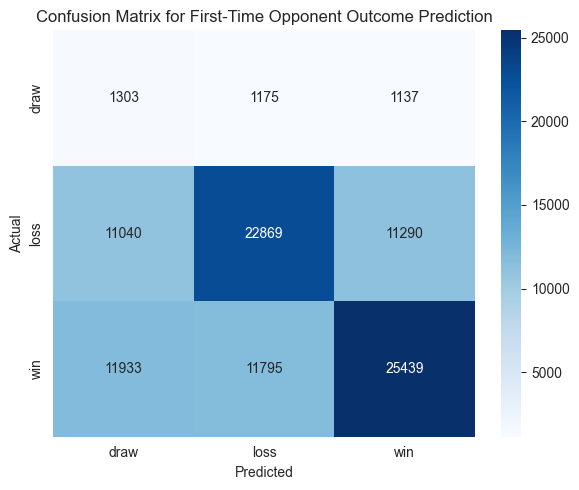

In [20]:
if 'model' in globals() and len(model_df) > 0:
    import joblib

    cm = confusion_matrix(y_test, pred, labels=model.classes_)
    cm_df = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix for First-Time Opponent Outcome Prediction")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    save_dir = Path("/Users/phamhoanghai/Ureca/Question_two/saved_first_time_opponent_model")
    save_dir.mkdir(parents=True, exist_ok=True)

    joblib.dump(model, save_dir / "model.joblib")
    joblib.dump(X_test, save_dir / "X_test.joblib")
    joblib.dump(y_test, save_dir / "y_test.joblib")
    joblib.dump(pred, save_dir / "pred.joblib")
    joblib.dump(proba, save_dir / "proba.joblib")
    joblib.dump(NUM_FEATURES, save_dir / "num_features.joblib")
    joblib.dump(CAT_FEATURES, save_dir / "cat_features.joblib")
    joblib.dump(evaluation_summary, save_dir / "evaluation_summary.joblib")

    print(f"Saved model artifacts to: {save_dir}")
else:
    print("Run the training cell first.")


## Load And Test Saved Model
You can reload the saved model artifacts from disk and re-evaluate them without retraining the model.


In [21]:
import joblib

save_dir = Path("/Users/phamhoanghai/Ureca/Question_two/saved_first_time_opponent_model")

if not save_dir.exists():
    print(f"Saved model directory not found: {save_dir}")
else:
    loaded_model = joblib.load(save_dir / "model.joblib")
    loaded_X_test = joblib.load(save_dir / "X_test.joblib")
    loaded_y_test = joblib.load(save_dir / "y_test.joblib")
    loaded_pred = joblib.load(save_dir / "pred.joblib")
    loaded_proba = joblib.load(save_dir / "proba.joblib")
    loaded_summary = joblib.load(save_dir / "evaluation_summary.joblib")

    print("Loaded saved model summary:")
    print(loaded_summary)
    print()
    print(classification_report(loaded_y_test, loaded_pred))

    loaded_cm = confusion_matrix(loaded_y_test, loaded_pred, labels=loaded_model.classes_)
    loaded_cm_df = pd.DataFrame(loaded_cm, index=loaded_model.classes_, columns=loaded_model.classes_)

    plt.figure(figsize=(6, 5))
    sns.heatmap(loaded_cm_df, annot=True, fmt="d", cmap="Greens")
    plt.title("Confusion Matrix From Reloaded Saved Model")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    sample_predictions = loaded_X_test.copy().head(10)
    sample_predictions["actual_outcome"] = loaded_y_test.iloc[:10].values
    sample_predictions["predicted_outcome"] = loaded_pred[:10]
    for class_name, probs in zip(loaded_model.classes_, loaded_proba[:10].T):
        sample_predictions[f"prob_{class_name}"] = probs

    display(sample_predictions)


Saved model directory not found: /Users/phamhoanghai/Ureca/Question_two/saved_first_time_opponent_model
